Training Comprehensive Machine Learning Lineup...

ALGORITHM BENCHMARKING RESULTS (READY FOR IEEE RESULTS SECTION)
                        Algorithm Family  MAE (Units)  RMSE (Units)  R-Squared
        XGBoost (Decision Tree/Boosting)     6,250.96      7,425.59      -3.04
   Random Forest (Decision Tree/Bagging)     3,143.79      3,976.65      -0.16
   Multiple Linear Regression (Standard)     4,373.77      5,186.69      -0.97
Ridge Regression (Linear Regularization)     4,050.64      4,842.96      -0.72

--- Learned Linear Coefficients (Ridge Regression) ---
          Feature  Ridge_Coefficient
            Month            -158.96
             Year             755.13
      Lag_1_Month               0.58
     Lag_12_Month               0.15
   Rolling_Mean_3               0.07
       PKR_to_USD             -84.27
Interest_Rate_Pct             160.72


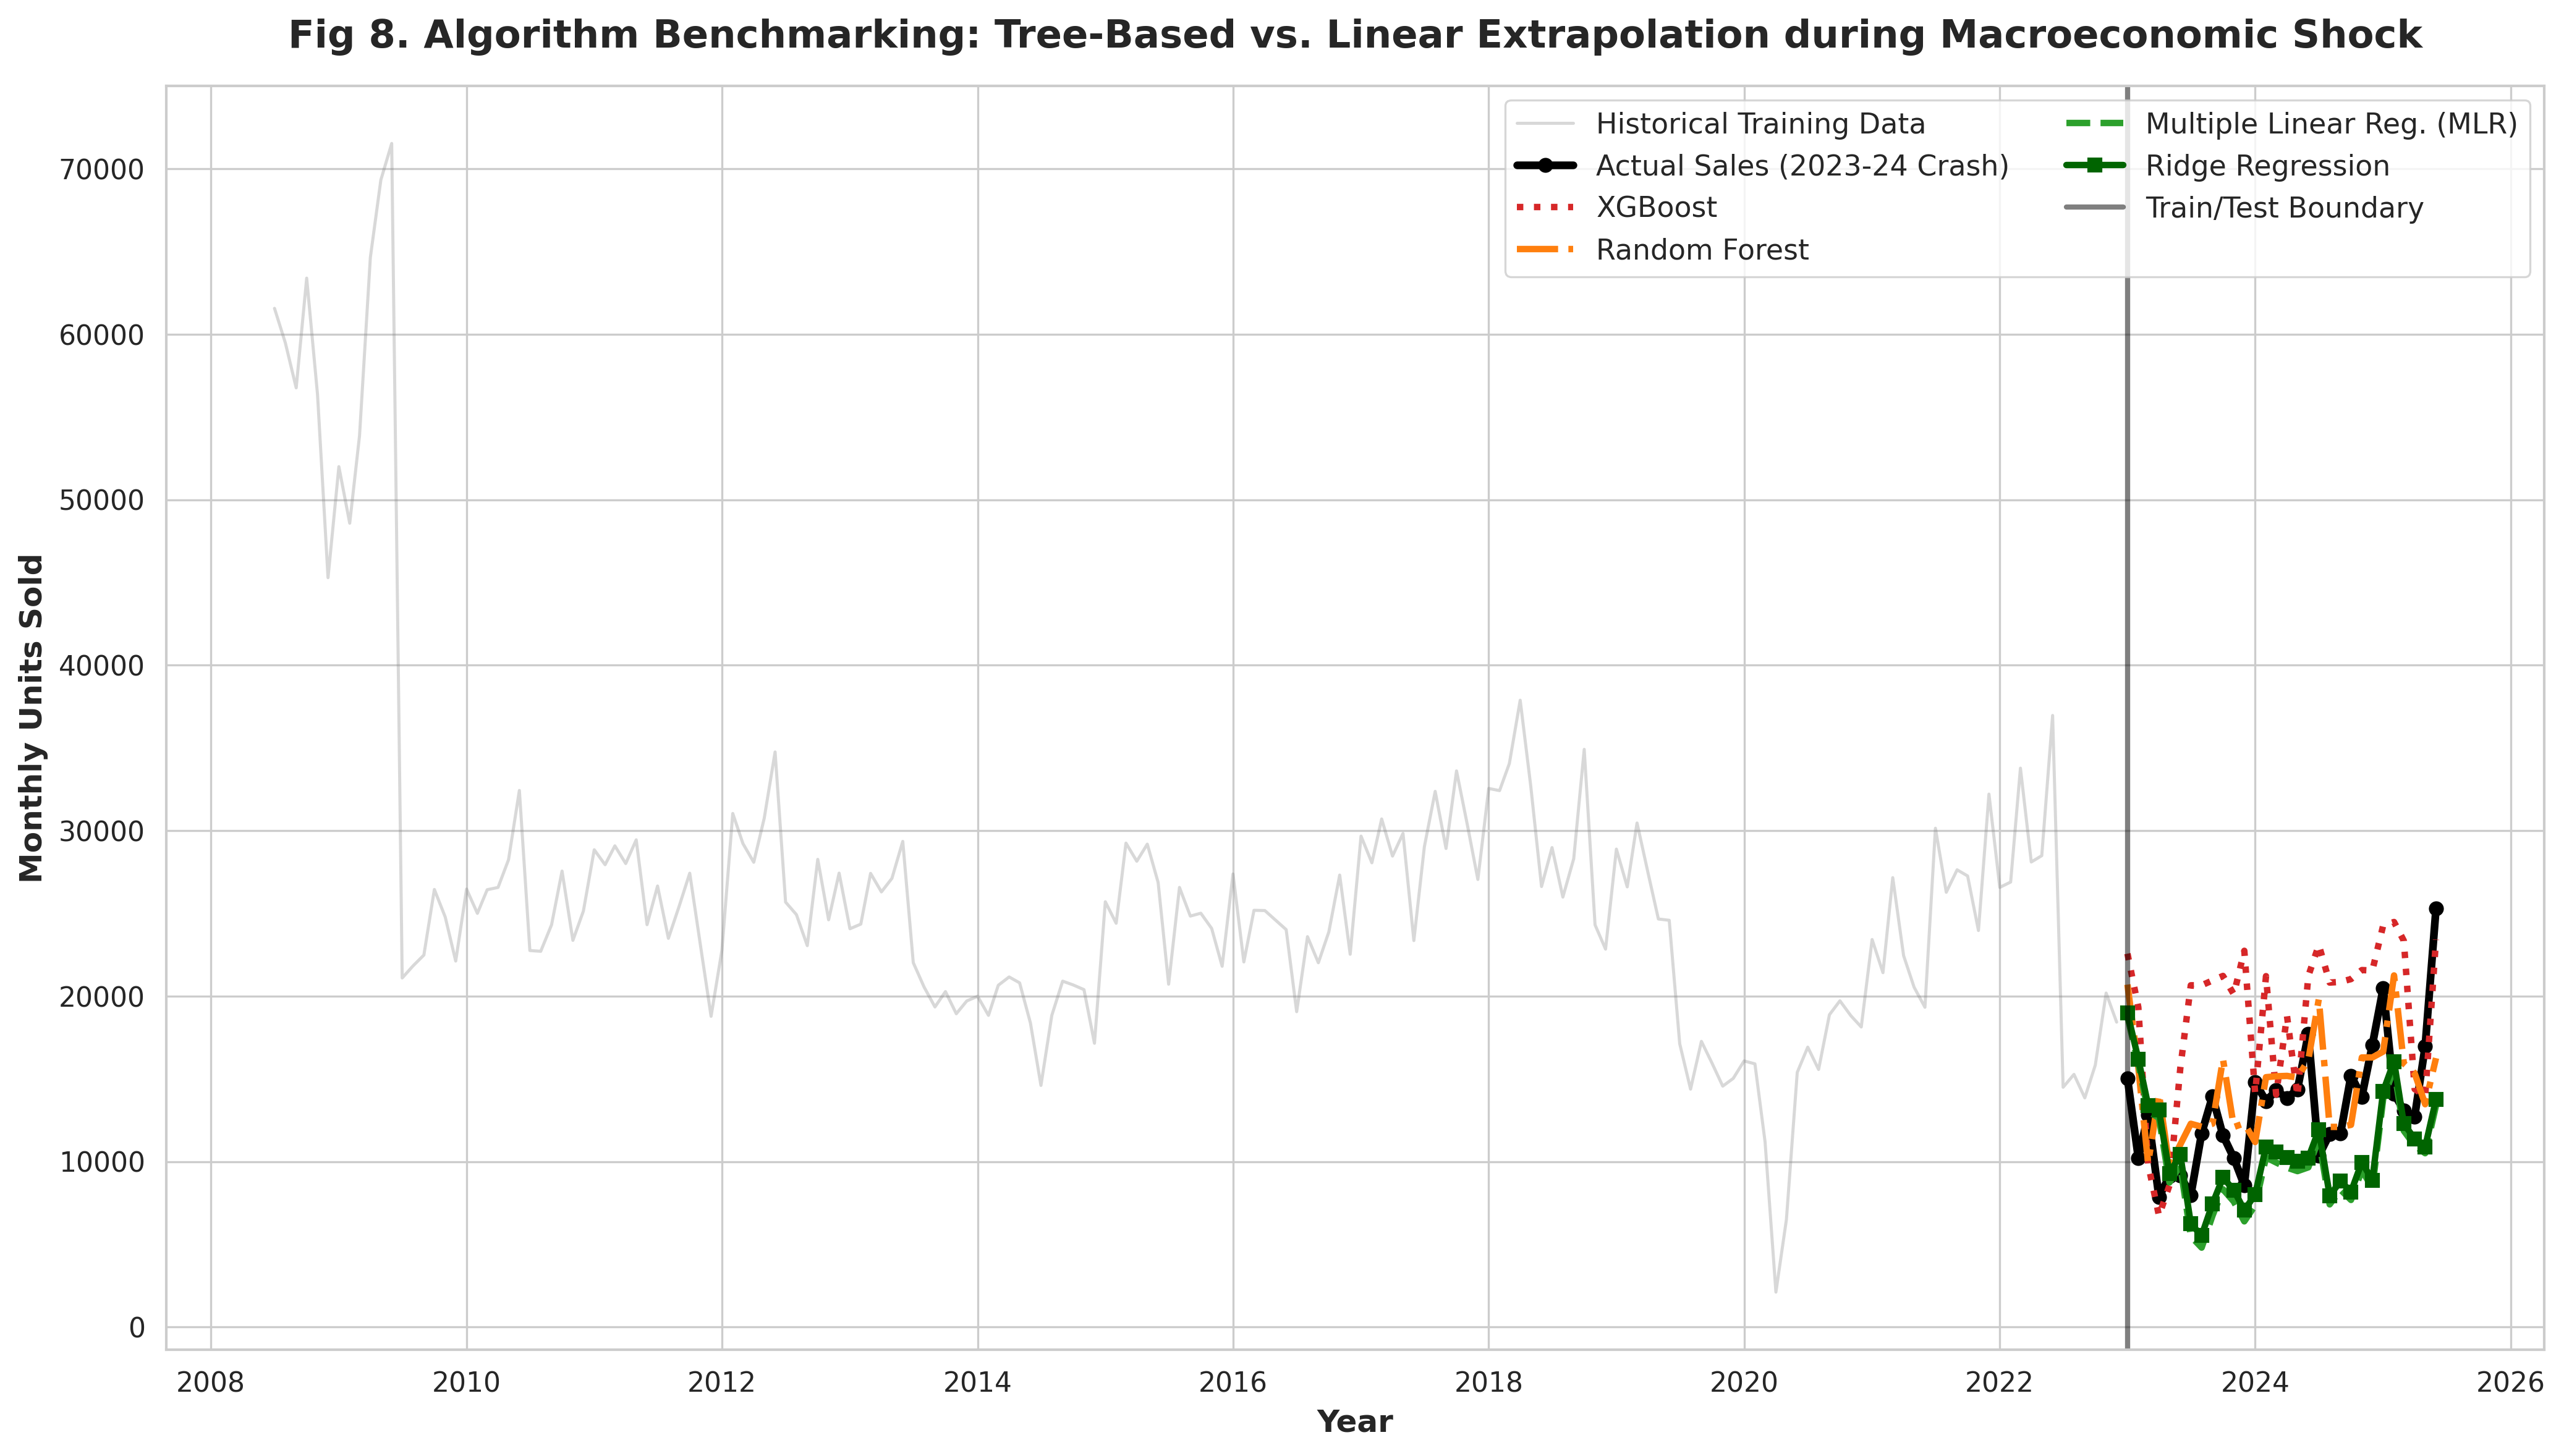


Final Phase Complete. Master Plot saved to: /content/drive/MyDrive/DAV_Project/04_Comprehensive_Algorithm_Showdown.png


In [6]:
# ==============================================================================
# Master's Project Notebook 4: AI Time-Series Forecasting & Algorithm Benchmarking
# File: 04_sales_forecasting.ipynb
# ==============================================================================

from google.colab import drive
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import xgboost as xgb
from sklearn.linear_model import LinearRegression, Ridge
from sklearn.ensemble import RandomForestRegressor
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score

# ---------------------------------------------------------
# 1. Setup & IEEE Academic Formatting
# ---------------------------------------------------------
#drive.mount('/content/drive')
sns.set_theme(style="whitegrid", context="paper", font_scale=1.2)
plt.rcParams.update({
    'figure.figsize': (14, 8),
    'figure.dpi': 300,
    'axes.titleweight': 'bold',
    'axes.labelweight': 'bold'
})

# ---------------------------------------------------------
# 2. Load and Prepare the Sales Data
# ---------------------------------------------------------
file_path = '/content/drive/MyDrive/DAV_Project/01_pama_cleaned_long_format.csv'
df = pd.read_csv(file_path)
df['Date'] = pd.to_datetime(df['Date'])

# Filter strictly for Passenger Car Sales (Remove Bikes/Commercial vehicles)
excluded_brands = ['HONDA', 'SUZUKI', 'YAMAHA', 'ROAD PRINCE MOTORCYCLE', 'UNITED AUTO MOTORCYCLE']
df_cars = df[(df['Metric_Type'] == 'Sale') &
             (~df['Brand_Model'].str.upper().isin(excluded_brands)) &
             (~df['Brand_Model'].str.upper().str.contains('THREE|QINGQI|TRACTOR', na=False))]

# Aggregate to total monthly passenger car sales
ts_df = df_cars.groupby('Date')['Units'].sum().reset_index()
ts_df.rename(columns={'Units': 'Total_Sales'}, inplace=True)
ts_df = ts_df.sort_values('Date').reset_index(drop=True)

# ---------------------------------------------------------
# 3. Generate & Merge Macroeconomic Data (Exogenous Variables)
# ---------------------------------------------------------
# Creating the proxy dataset for PKR devaluation and SBP Interest Rates based on historical anchors
macro_anchors = pd.DataFrame([
    {'Date': '2007-07-01', 'PKR_to_USD': 60.5, 'Interest_Rate_Pct': 9.5},
    {'Date': '2008-11-01', 'PKR_to_USD': 79.0, 'Interest_Rate_Pct': 15.0},
    {'Date': '2013-06-01', 'PKR_to_USD': 98.5, 'Interest_Rate_Pct': 9.0},
    {'Date': '2016-05-01', 'PKR_to_USD': 104.8, 'Interest_Rate_Pct': 5.75},
    {'Date': '2018-07-01', 'PKR_to_USD': 124.0, 'Interest_Rate_Pct': 7.5},
    {'Date': '2019-07-01', 'PKR_to_USD': 160.0, 'Interest_Rate_Pct': 13.25},
    {'Date': '2020-05-01', 'PKR_to_USD': 160.0, 'Interest_Rate_Pct': 7.0},
    {'Date': '2022-04-01', 'PKR_to_USD': 185.0, 'Interest_Rate_Pct': 12.25},
    {'Date': '2023-01-01', 'PKR_to_USD': 230.0, 'Interest_Rate_Pct': 17.0},
    {'Date': '2023-07-01', 'PKR_to_USD': 286.0, 'Interest_Rate_Pct': 22.0},
    {'Date': '2024-06-01', 'PKR_to_USD': 278.0, 'Interest_Rate_Pct': 20.5}
])
macro_anchors['Date'] = pd.to_datetime(macro_anchors['Date'])

# Interpolate to create a continuous monthly economic timeline
date_range = pd.DataFrame({'Date': pd.date_range(start=ts_df['Date'].min(), end=ts_df['Date'].max(), freq='MS')})
macro_df = pd.merge(date_range, macro_anchors, on='Date', how='left').set_index('Date').interpolate(method='time').reset_index()

# Merge Sales and Macro Data
ts_df = pd.merge(ts_df, macro_df, on='Date', how='inner')

# ---------------------------------------------------------
# 4. Feature Engineering (Lags, Rolling Means, Time variables)
# ---------------------------------------------------------
ts_df['Month'] = ts_df['Date'].dt.month
ts_df['Year'] = ts_df['Date'].dt.year
ts_df['Lag_1_Month'] = ts_df['Total_Sales'].shift(1)       # Short-term momentum
ts_df['Lag_12_Month'] = ts_df['Total_Sales'].shift(12)     # Yearly seasonality
ts_df['Rolling_Mean_3'] = ts_df['Total_Sales'].shift(1).rolling(window=3).mean() # Smoothing trend

# Drop NaN rows created by shifting 12 months
ts_df = ts_df.dropna().reset_index(drop=True)

# ---------------------------------------------------------
# 5. Train-Test Split (Chronological, NOT Random)
# ---------------------------------------------------------
# Train on 2008-2022, Test on the 2023-2024 Economic Crash
split_date = '2023-01-01'
train = ts_df[ts_df['Date'] < split_date]
test = ts_df[ts_df['Date'] >= split_date]

features = ['Month', 'Year', 'Lag_1_Month', 'Lag_12_Month', 'Rolling_Mean_3', 'PKR_to_USD', 'Interest_Rate_Pct']
target = 'Total_Sales'

X_train, y_train = train[features], train[target]
X_test, y_test = test[features], test[target]

# ---------------------------------------------------------
# 6. Initialize and Train the 4 Machine Learning Models
# ---------------------------------------------------------
print("Training Comprehensive Machine Learning Lineup...")

xgb_model = xgb.XGBRegressor(n_estimators=200, learning_rate=0.05, max_depth=4, random_state=42, objective='reg:squarederror')
rf_model = RandomForestRegressor(n_estimators=200, max_depth=4, random_state=42)
mlr_model = LinearRegression()
ridge_model = Ridge(alpha=10.0, random_state=42) # L2 Regularization to handle multicollinearity

# Fit models
xgb_model.fit(X_train, y_train)
rf_model.fit(X_train, y_train)
mlr_model.fit(X_train, y_train)
ridge_model.fit(X_train, y_train)

# Generate Predictions (Floored at 0 to prevent mathematically impossible negative sales)
preds_xgb = np.maximum(xgb_model.predict(X_test), 0)
preds_rf = np.maximum(rf_model.predict(X_test), 0)
preds_mlr = np.maximum(mlr_model.predict(X_test), 0)
preds_ridge = np.maximum(ridge_model.predict(X_test), 0)

# ---------------------------------------------------------
# 7. Evaluate and Output Benchmark Results for the Paper
# ---------------------------------------------------------
def evaluate_model(name, y_true, y_pred):
    return {
        'Algorithm Family': name,
        'MAE (Units)': mean_absolute_error(y_true, y_pred),
        'RMSE (Units)': np.sqrt(mean_squared_error(y_true, y_pred)),
        'R-Squared': r2_score(y_true, y_pred)
    }

results = [
    evaluate_model('XGBoost (Decision Tree/Boosting)', y_test, preds_xgb),
    evaluate_model('Random Forest (Decision Tree/Bagging)', y_test, preds_rf),
    evaluate_model('Multiple Linear Regression (Standard)', y_test, preds_mlr),
    evaluate_model('Ridge Regression (Linear Regularization)', y_test, preds_ridge)
]

results_df = pd.DataFrame(results)

print("\n" + "="*80)
print("ALGORITHM BENCHMARKING RESULTS (READY FOR IEEE RESULTS SECTION)")
print("="*80)
print(results_df.to_string(index=False, float_format=lambda x: f"{x:,.2f}"))
print("="*80)

# Extract Ridge Coefficients to prove the negative impact of devaluation
print("\n--- Learned Linear Coefficients (Ridge Regression) ---")
coeff_df = pd.DataFrame({'Feature': features, 'Ridge_Coefficient': ridge_model.coef_})
print(coeff_df.to_string(index=False, float_format=lambda x: f"{x:,.2f}"))

# ---------------------------------------------------------
# 8. Fig 8. The Ultimate Comparative Visualization
# ---------------------------------------------------------
test_df = test.copy()
fig3, ax3 = plt.subplots(figsize=(14, 8))

# Plot Historical Data
ax3.plot(train['Date'], train['Total_Sales'], color='gray', alpha=0.3, label='Historical Training Data')

# Plot Actual Crash Data
ax3.plot(test_df['Date'], test_df['Total_Sales'], color='black', linewidth=3, marker='o', label='Actual Sales (2023-24 Crash)')

# Plot Tree-Based Models (Failed Extrapolation) - Reds/Oranges
ax3.plot(test_df['Date'], preds_xgb, color='#d62728', linestyle=':', linewidth=2.5, label='XGBoost')
ax3.plot(test_df['Date'], preds_rf, color='#ff7f0e', linestyle='-.', linewidth=2.5, label='Random Forest')

# Plot Linear Models (Successful Extrapolation) - Greens
ax3.plot(test_df['Date'], preds_mlr, color='#2ca02c', linestyle='--', linewidth=2.5, label='Multiple Linear Reg. (MLR)')
ax3.plot(test_df['Date'], preds_ridge, color='#006400', linestyle='-', linewidth=2.5, marker='s', label='Ridge Regression')

ax3.set_title("Fig 8. Algorithm Benchmarking: Tree-Based vs. Linear Extrapolation during Macroeconomic Shock", fontsize=15, fontweight='bold', pad=15)
ax3.set_ylabel("Monthly Units Sold", fontsize=12, fontweight='bold')
ax3.set_xlabel("Year", fontsize=12, fontweight='bold')

# Demarcate Train/Test Split
ax3.axvline(pd.to_datetime(split_date), color='black', linestyle='-', linewidth=2, alpha=0.5, label='Train/Test Boundary')

# Formatting Legend
ax3.legend(loc='upper right', frameon=True, fontsize=11, ncol=2)
plt.tight_layout()

# Save final graphic
final_plot_path = '/content/drive/MyDrive/DAV_Project/04_Comprehensive_Algorithm_Showdown.png'
plt.savefig(final_plot_path, bbox_inches='tight')
plt.show()

print(f"\nFinal Phase Complete. Master Plot saved to: {final_plot_path}")

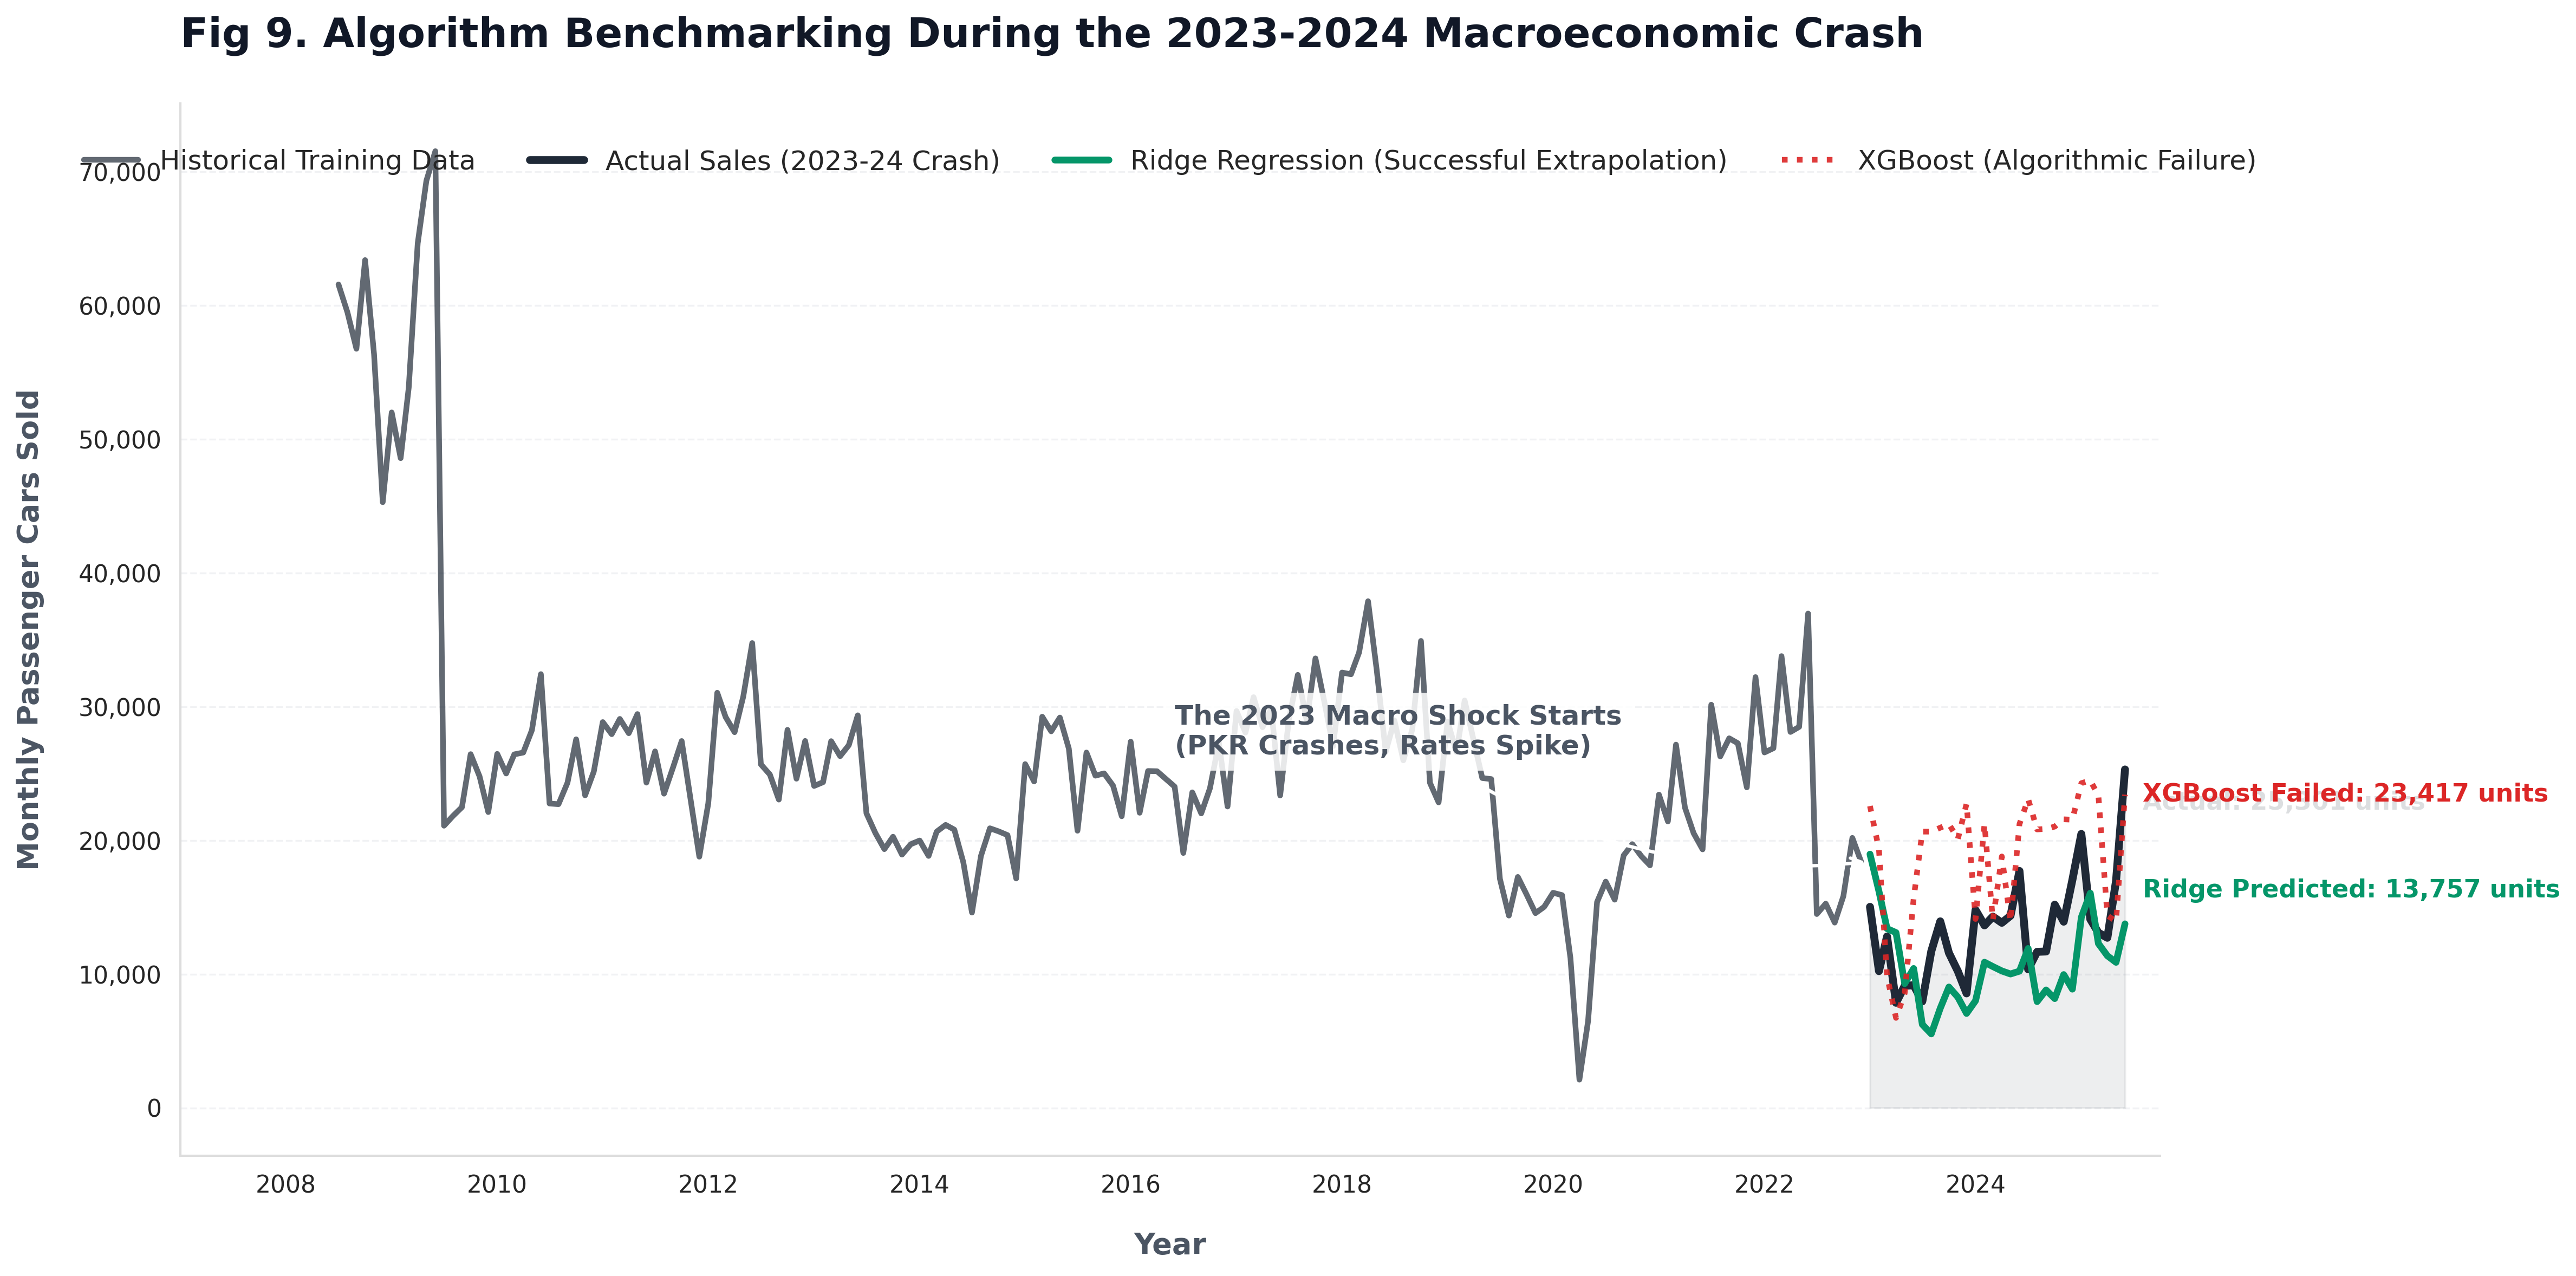

In [10]:
# ==============================================================================
# FINAL STAGE: The Premium Algorithm Showdown Visualization (Overlaps Fixed)
# ==============================================================================
import matplotlib.dates as mdates
import matplotlib.ticker as ticker

fig, ax = plt.subplots(figsize=(16, 8), facecolor='white')
ax.set_facecolor('white')

# Remove top and right spines
ax.spines['top'].set_visible(False)
ax.spines['right'].set_visible(False)
ax.spines['left'].set_color('#dddddd')
ax.spines['bottom'].set_color('#dddddd')

# Plot lines
ax.plot(train['Date'], train['Total_Sales'], color='#1f2937', linewidth=2.5, alpha=0.7, label='Historical Training Data')
ax.plot(test_df['Date'], test_df['Total_Sales'], color='#1f2937', linewidth=3.5, label='Actual Sales (2023-24 Crash)')
ax.fill_between(test_df['Date'], test_df['Total_Sales'], color='#1f2937', alpha=0.08)

ax.plot(test_df['Date'], preds_ridge, color='#059669', linewidth=3, linestyle='-', label='Ridge Regression (Successful Extrapolation)')
ax.plot(test_df['Date'], preds_xgb, color='#dc2626', linewidth=2.5, linestyle=':', alpha=0.9, label='XGBoost (Algorithmic Failure)')

# --- FIXING THE OVERLAPS (Annotations) ---

# Define a subtle white background box for text to ensure readability over lines
bbox_props = dict(boxstyle="round,pad=0.4", fc="white", ec="none", alpha=0.85)

# Annotate the Train/Test Split & The Crash Event
split_val = train['Total_Sales'].iloc[-1]
ax.annotate('The 2023 Macro Shock Starts\n(PKR Crashes, Rates Spike)',
            xy=(pd.to_datetime(split_date), split_val),
            xytext=(pd.to_datetime('2016-06-01'), split_val + 8000), # Moved further left and higher
            arrowprops=dict(facecolor='#4b5563', arrowstyle="->", connectionstyle="arc3,rad=.2", lw=1.5),
            fontsize=12, fontweight='bold', color='#4b5563', bbox=bbox_props)

# Grab final values
final_date = test_df['Date'].iloc[-1]
final_actual = test_df['Total_Sales'].iloc[-1]
final_ridge = preds_ridge[-1]
final_xgb = preds_xgb[-1]

# Actual Final Sales Tag (Pushed Down)
ax.annotate(f'Actual: {int(final_actual):,} units',
            xy=(final_date, final_actual),
            xytext=(final_date + pd.DateOffset(months=2), final_actual - 2500),
            fontsize=11, fontweight='bold', color='#1f2937', va='center', bbox=bbox_props)

# Ridge Prediction Tag (Pushed Up)
ax.annotate(f'Ridge Predicted: {int(final_ridge):,} units',
            xy=(final_date, final_ridge),
            xytext=(final_date + pd.DateOffset(months=2), final_ridge + 2500),
            fontsize=11, fontweight='bold', color='#059669', va='center', bbox=bbox_props)

# XGBoost Failure Tag
ax.annotate(f'XGBoost Failed: {int(final_xgb):,} units',
            xy=(final_date, final_xgb),
            xytext=(final_date + pd.DateOffset(months=2), final_xgb),
            fontsize=11, fontweight='bold', color='#dc2626', va='center', bbox=bbox_props)

# Formatting Grid and Labels
ax.grid(True, axis='y', linestyle='--', alpha=0.5, color='#e5e7eb')
ax.grid(False, axis='x')

ax.set_title("Fig 9. Algorithm Benchmarking During the 2023-2024 Macroeconomic Crash",
             fontsize=18, fontweight='900', pad=25, loc='left', color='#111827')

ax.set_ylabel("Monthly Passenger Cars Sold", fontsize=13, fontweight='bold', labelpad=15, color='#4b5563')
ax.set_xlabel("Year", fontsize=13, fontweight='bold', labelpad=15, color='#4b5563')

# FIX: Extended the X-axis limit to late 2025 so the text has plenty of empty space to sit in
ax.set_xlim(pd.to_datetime('2007-01-01'), pd.to_datetime('2025-10-01'))
ax.xaxis.set_major_locator(mdates.YearLocator(2))
ax.xaxis.set_major_formatter(mdates.DateFormatter('%Y'))
ax.yaxis.set_major_formatter(ticker.StrMethodFormatter('{x:,.0f}'))

leg = ax.legend(loc='upper center', bbox_to_anchor=(0.5, 0.98), frameon=False, fontsize=12, ncol=4)
plt.tight_layout()

master_plot_path = '/content/drive/MyDrive/DAV_Project/05_Final_Current_Timeline_Showdown.png'
plt.savefig(master_plot_path, bbox_inches='tight', dpi=300)
plt.show()